<a href="https://colab.research.google.com/github/mtryptnkr-study/Diabetes-Prediction/blob/main/DiabetesPredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PIMA Diabetes Dataset from UCI Machine Learning Repository
* The data is collected from Female Gender only.

# Methodology

* Collection of Data
* Pre-process the Data
  * Standardizing
* Train-test split
* Feed it to a ML model
  * Used SVM classifier model
* Train our model
* Test our model

# Importing the dependencies

In [439]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # to standardize the data to common range
from sklearn import svm
from sklearn.metrics import accuracy_score

# Data collection and analysis

In [440]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Machine Learning Projects/Diabetes Prediction/Dataset/diabetes.csv")

In [441]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


* 1 represents a diabetic patient
* 0 represents a non-diabetic patient

In [442]:
data.shape

(768, 9)

In [443]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Statistical Measures

In [444]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [445]:
data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [446]:
data.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


# Separating Data and Labels

In [447]:
X = data.drop(columns='Outcome', axis=1) # dropping a column so axis = 1
y = data['Outcome']

In [448]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [449]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


# Standardizing the Data
* As the range of values of each feature differs, it will hamper the predictions.
* We will standardize the data in a particular range.

In [450]:
scaler = StandardScaler()

In [451]:
scaler.fit(X)

StandardScaler()

In [452]:
standardized_data = scaler.transform(X)

In [453]:
print(standardized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [454]:
# storing standardized data in X
X = standardized_data

## Splitting the data

In [455]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [456]:
print(X.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(768, 8) (614, 8) (154, 8) (614,) (154,)


# Training the model

In [457]:
classifier = svm.SVC(kernel='linear')

In [458]:
# training the model
classifier.fit(X_train, y_train)

SVC(kernel='linear')

## Model Evaluation

In [459]:
# accuracy score on the training data
X_train_prediction = classifier.predict(X_train)
training_data_acc = accuracy_score(X_train_prediction, y_train)
print(f"The training model accuracy is {training_data_acc}")

The training model accuracy is 0.7915309446254072


In [460]:
# accuracy score on the testing data
X_test_prediction = classifier.predict(X_test)
testing_data_acc = accuracy_score(X_test_prediction, y_test)
print(f"The testing model accuracy is {testing_data_acc}")

The testing model accuracy is 0.7207792207792207


# Predictor

In [461]:
input_data = (4, 110, 92, 0, 0, 37.6, 0.191, 30)

# converting it into numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshaping the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# standardize the input_data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

[[ 0.04601433 -0.34096773  1.18359575 -1.28821221 -0.69289057  0.71168975
  -0.84827977 -0.27575966]]


In [462]:
prediction = classifier.predict(std_data)

if prediction[0] == 0:
  print("The person is not diabetic")
else:
  print("The person is diabetic")

The person is not diabetic




---



In [463]:
import warnings
warnings.filterwarnings('ignore')

# Advanced Prediction


## Methodology for Feature Engineering
* Missing Values Detection (including 0 in PIDD)
* Data Distribution of features for healthy and diabetic category & IQR based outlier removal
* Inputting MVs with mean/median/regression imputation based on data distribution
* Derived Features from PIDD
* Permutation Importance of features of PIDD and derived features
* Discarding the negative weight features (```SkinThickness```) and construct the dataset with remaining features.
* ML Model

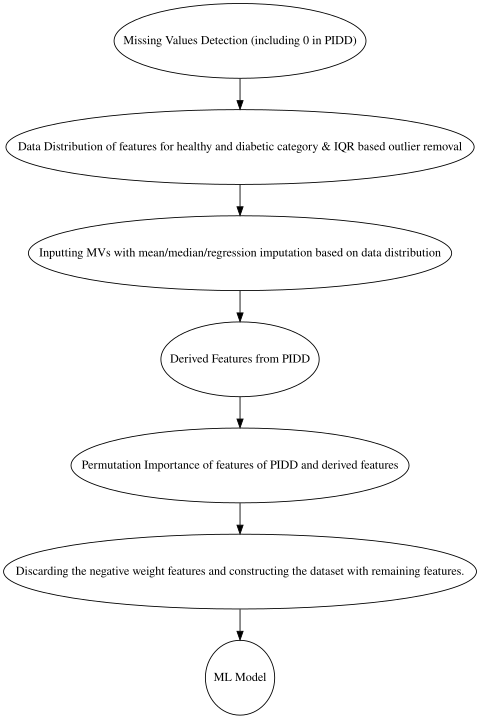

In [464]:
import graphviz

# Create the graph
dot = graphviz.Digraph('FeatureEngineering', comment='My Workflow')

# Set max width and height in inches
dot.attr(size='10,10!')

# Make the fonts and nodes smaller to match the size
dot.attr('node', fontsize='14', height='1.2')

# Define your steps (Nodes)
dot.node('A', 'Missing Values Detection (including 0 in PIDD)')
dot.node('B', 'Data Distribution of features for healthy and diabetic category & IQR based outlier removal')
dot.node('C', 'Inputting MVs with mean/median/regression imputation based on data distribution')
dot.node('D', 'Derived Features from PIDD')
dot.node('E', 'Permutation Importance of features of PIDD and derived features')
dot.node('F', 'Discarding the negative weight features and constructing the dataset with remaining features.')
dot.node('G', 'ML Model')

# Define the flow (Edges)
dot.edges(['AB', 'BC', 'CD', 'DE', 'EF', 'FG'])

# Render it directly in the cell
dot


### Handling Missing Values


In [465]:
# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Machine Learning Projects/Diabetes Prediction/Dataset/diabetes.csv")

# List of columns where 0 is an invalid value and should be NA
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN only in these specific columns
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

In [466]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Null Values in the dataset

In [467]:
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [468]:
# Percentage of missing values
missing_percent = (df.isnull().sum() / 768) * 100
print(missing_percent.map("{:.2f}%".format))


Pregnancies                  0.00%
Glucose                      0.65%
BloodPressure                4.56%
SkinThickness               29.56%
Insulin                     48.70%
BMI                          1.43%
DiabetesPedigreeFunction     0.00%
Age                          0.00%
Outcome                      0.00%
dtype: object


#### Observation
* ```Insulin``` and ```SkinThickness``` has the highest number of MVs.
* Zero doesn't make any sense in healthcare domain, so these are considered as MVs.
* It is essential to have statistical insight into features before performing the imputation process.


### Outlier Analysis of PIDD features

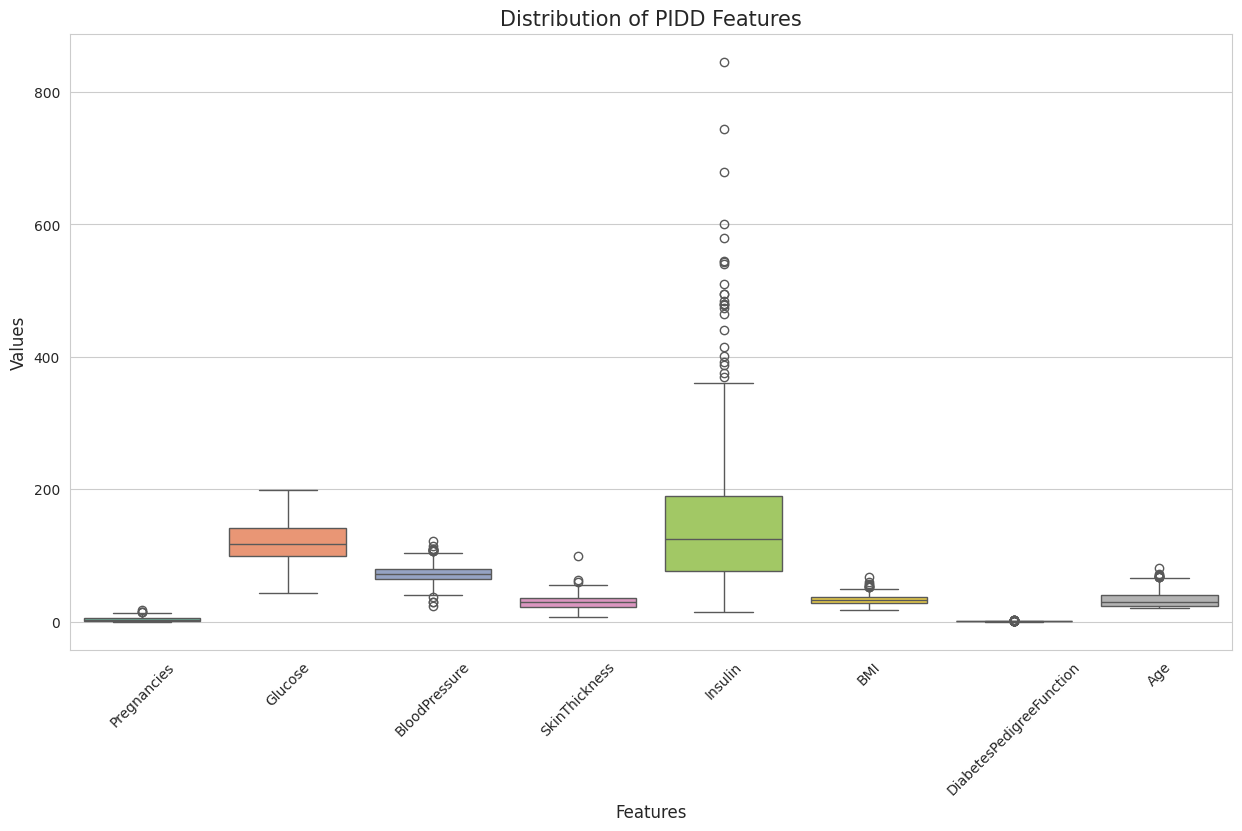

In [469]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

df_melted = df.drop(columns=['Outcome']).melt()

sns.boxplot(x='variable', y='value', data=df_melted, palette="Set2")

plt.title('Distribution of PIDD Features', fontsize=15)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.xticks(rotation=45) # Rotates feature names for better fit

plt.show()

### Imputation of MVs
* ```SkinThickness```, ```BloodPressure``` and ```BMI``` are imputed using thier respective median value.
* ```Glucose``` and ```Insulin``` are imputed with mean values.

Distribution before imputation

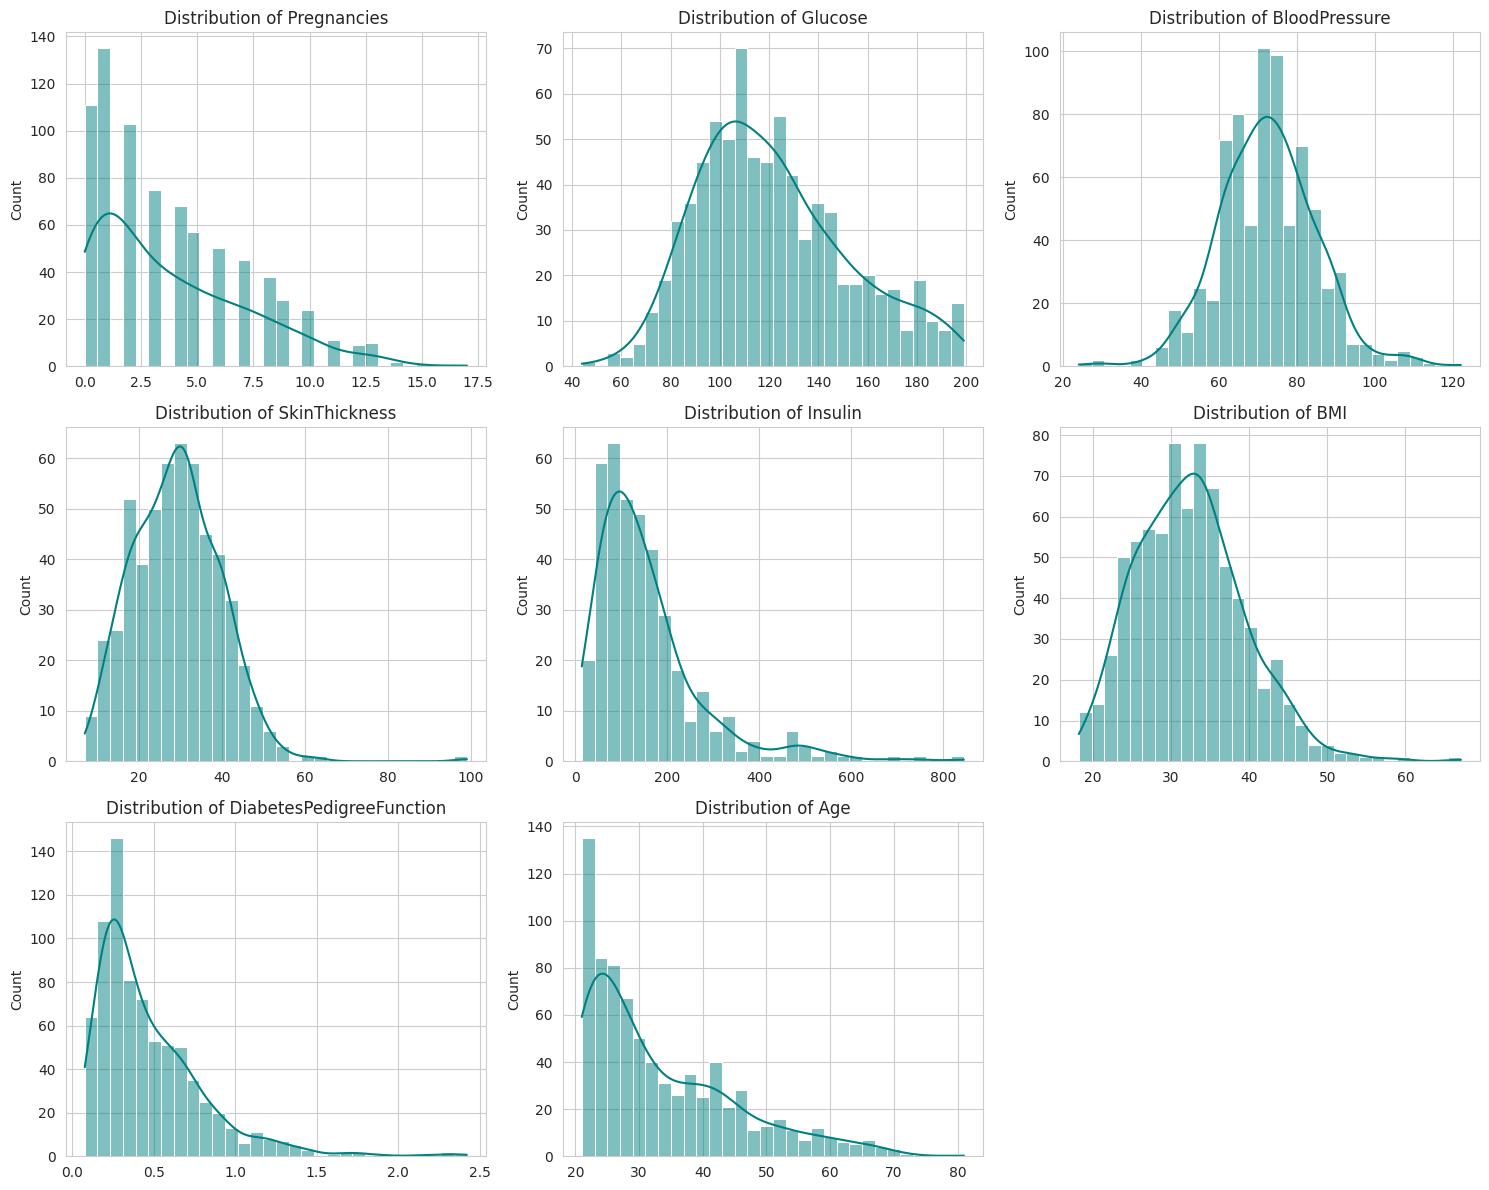

In [470]:
# Set the figure size for a grid of plots
plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")

# Get list of features excluding the 'Outcome'
features = df.columns.drop('Outcome')

# Loop through each feature and create a subplot
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1) # Create a 3x3 grid
    sns.histplot(df[col], kde=True, color='teal', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('') # Clean up x-labels for better fit

plt.tight_layout()
plt.show()


In [471]:
# create a "mask" to remember where the gaps were
null_mask = df.isnull()

In [472]:
# Impute Glucose and Insulin
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].mean())

df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].median())

In [473]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Distribution after imputation with mean/median values

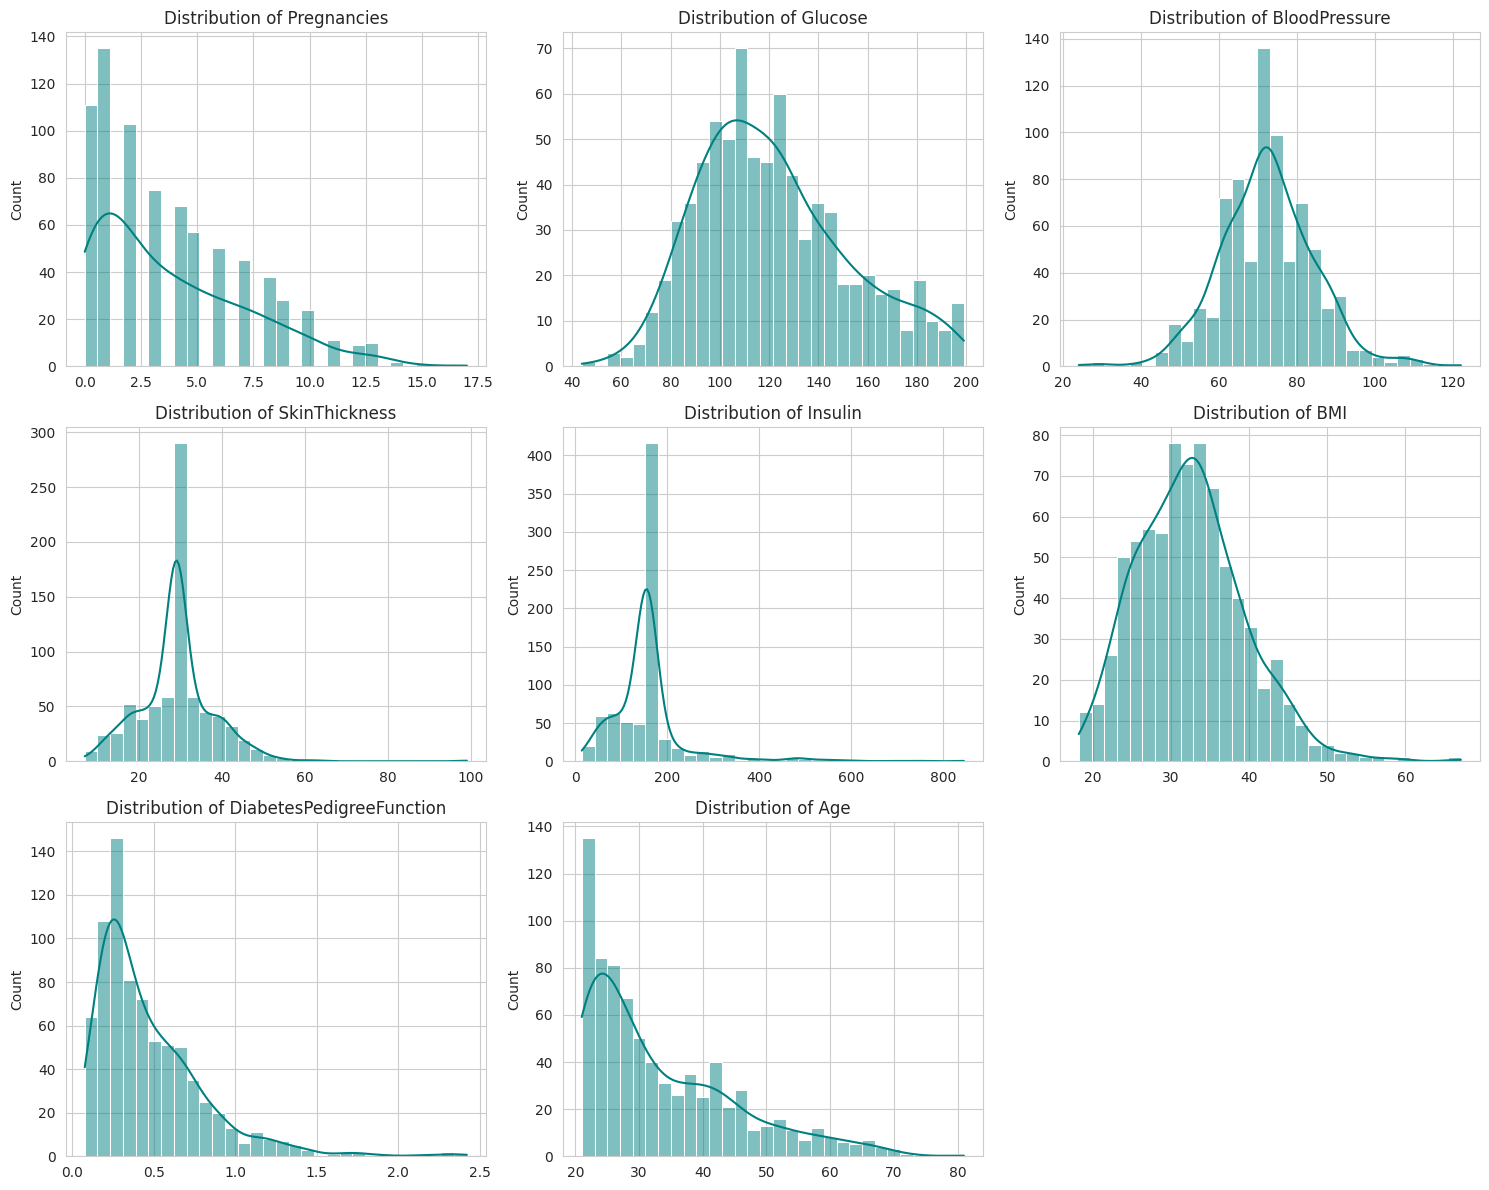

In [474]:
# Set the figure size for a grid of plots
plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")

# Get list of features excluding the 'Outcome'
features = df.columns.drop('Outcome')

# Loop through each feature and create a subplot
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1) # Create a 3x3 grid
    sns.histplot(df[col], kde=True, color='teal', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('') # Clean up x-labels for better fit

plt.tight_layout()
plt.show()

### Correlation Matrix

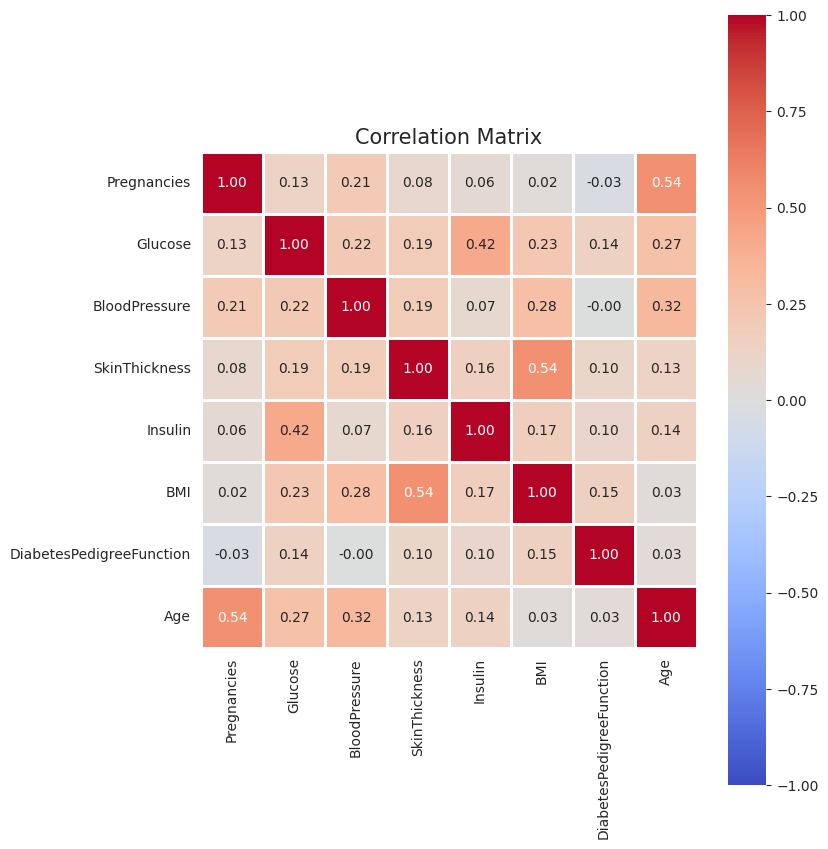

In [475]:
corr_features = df.drop(columns=['Outcome']).corr()

plt.figure(figsize=(8,10))

sns.heatmap(corr_features,
            annot=True,          # Shows the correlation coefficients
            fmt=".2f",           # Limits to two decimal places
            cmap='coolwarm',     # Red for positive, blue for negative
            vmin=-1, vmax=1,     # Sets the range for the color bar
            center=0,
            square=True,
            linewidths=.75)

plt.title('Correlation Matrix', fontsize=15)
plt.show()


#### Observations
* ```Glucose``` has a positive weak linear association with all other features. This indicates an increase in ```Glucose``` level of patients will lead to an increase of all other features' value.
* ```BloodPressure``` has a positive weak linear association with all other features. This indicates an increase in ```BloodPressure``` level of patients will lead to an increase of all other features' value.
* ```SkinThickness``` has a positive weak linear association with all other features except ```BMI```. It has a strong linear association with ```BMI```.
* ```DiabetesPedigreeFunction``` has a weak negative relationship with ```Pregnancies``` and weak positive relationship with other features.
* ```Age``` has a stronger linear association with ```Pregnancies```, ```Glucose``` and ```BloodPresure```. The rest of features have a weak linear association with ```Age```.

As we found the relationship between the features, it makes more sense by imputing them using a iterative regressor.

#### Imputation using Iterative Linear Regression

In [476]:
from sklearn.linear_model import LinearRegression

# Adding GAUSSIAN NOISE
# This adds a bit of variety so the regression has better "intuition"
features_to_refine = ['Glucose', 'Insulin', 'SkinThickness']

for col in features_to_refine:
    # Generate noise (mean=0, small spread) for only the missing rows
    noise = np.random.normal(0, df[col].std() * 0.05, size=null_mask[col].sum())
    df.loc[null_mask[col], col] += noise

    # Text Rule: If noise makes it negative or zero, reset to mean
    df[col] = np.where(df[col] <= 0, df[col].mean(), df[col])

In [477]:
# ITERATIVE REGRESSION
for iteration in range(5): # Repeating 5 times to let values stabilize
    for target_col in features_to_refine:
        # Split into training (real data) and predict (originally missing)
        train_df = df[~null_mask[target_col]]
        predict_df = df[null_mask[target_col]]

        if predict_df.empty: continue

        X_train = train_df.drop(columns=[target_col])
        y_train = train_df[target_col]
        X_predict = predict_df.drop(columns=[target_col])

        # Train and Predict
        model = LinearRegression()
        model.fit(X_train, y_train)
        preds = model.predict(X_predict)

        # Again, ensure no negative values from regression
        preds = np.where(preds <= 0, df[target_col].mean(), preds)

        # Update the dataframe
        df.loc[null_mask[target_col], target_col] = preds

print("Imputation sequence is complete.")

Imputation sequence is complete.


Distribution after Iterative Imputation

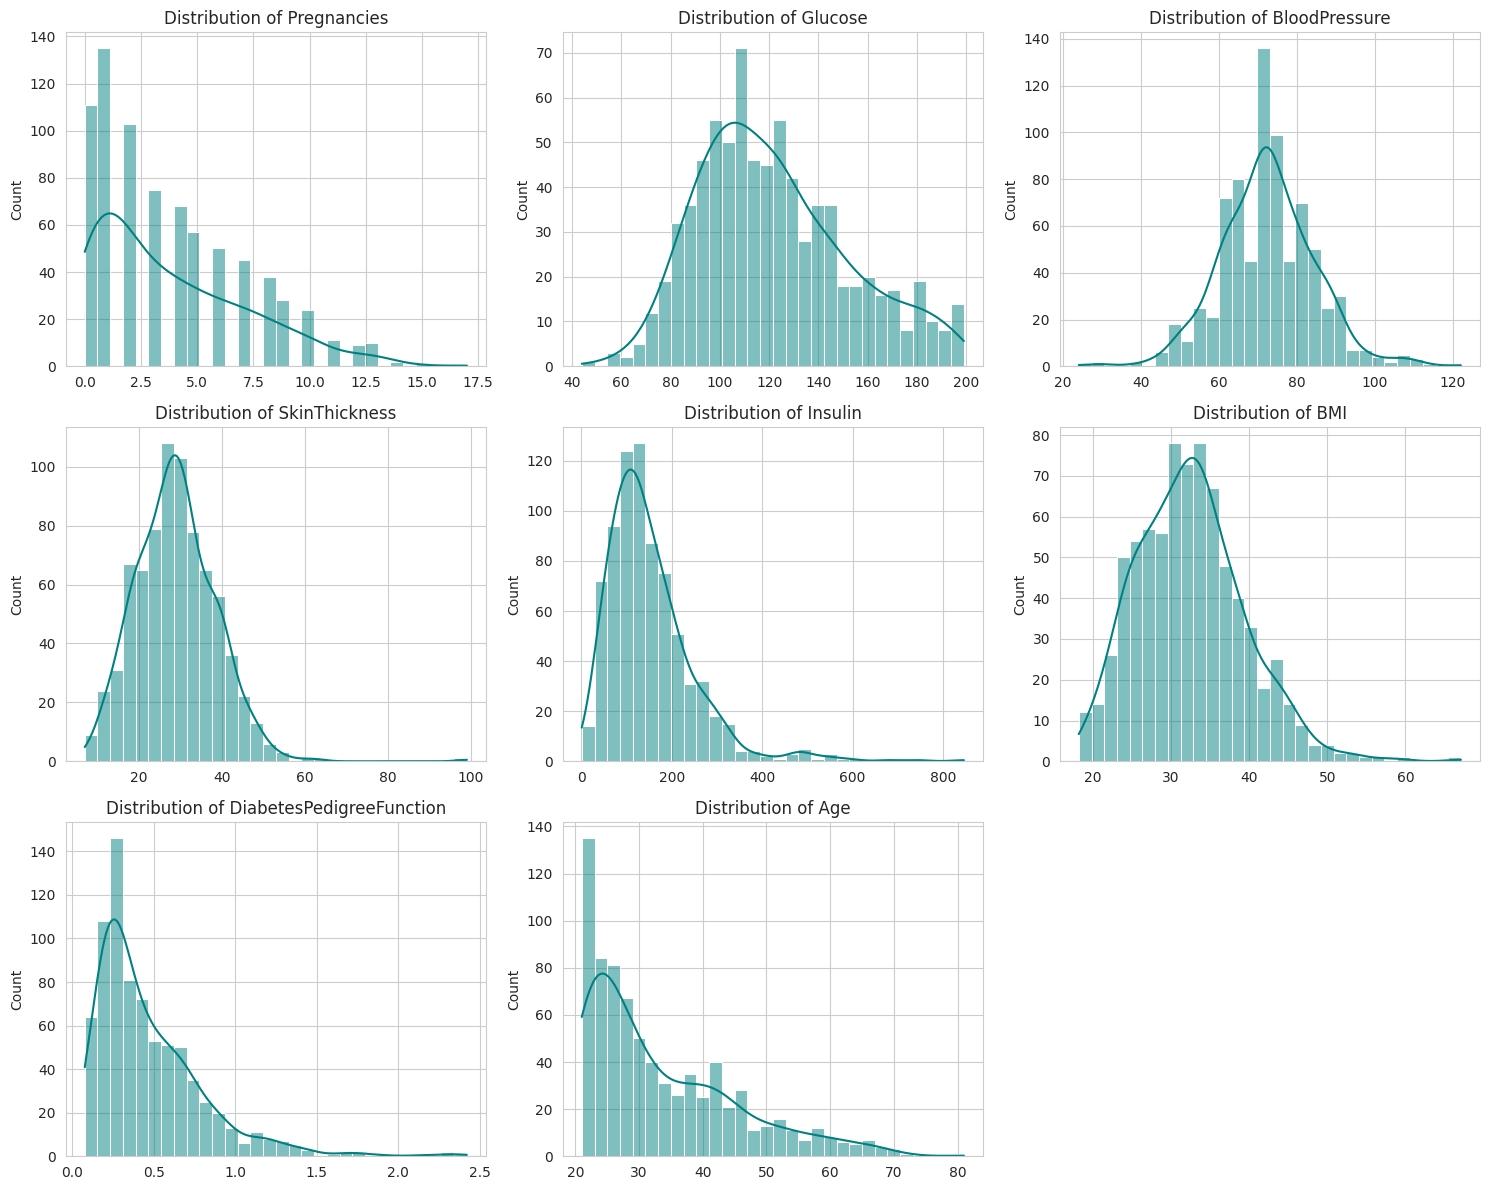

In [478]:
# Set the figure size for a grid of plots
plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")

# Get list of features excluding the 'Outcome'
features = df.columns.drop('Outcome')

# Loop through each feature and create a subplot
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1) # Create a 3x3 grid
    sns.histplot(df[col], kde=True, color='teal', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('') # Clean up x-labels for better fit

plt.tight_layout()
plt.show()

#### Observations
* ```Insulin``` is still not perfectly Gaussian even after iterative imputation because it had the most MVs.
*

In [479]:
# Calculate variance for all features
variance_results = df.var()

# Display the results
print("Variance of PIDD Features:")
print(variance_results)

Variance of PIDD Features:
Pregnancies                   11.354056
Glucose                      929.616911
BloodPressure                146.328741
SkinThickness                 91.068152
Insulin                     9617.193341
BMI                           47.268056
DiabetesPedigreeFunction       0.109779
Age                          138.303046
Outcome                        0.227483
dtype: float64


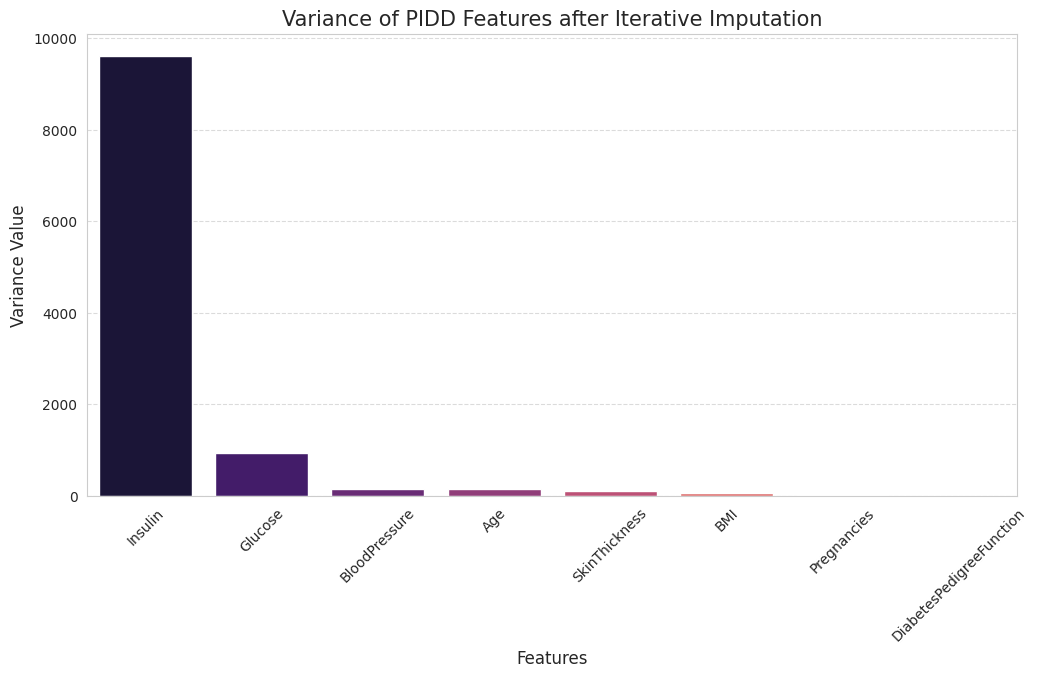

In [480]:
df_copy = df.copy()
df_copy = df_copy.drop(columns=['Outcome'])
# Calculate variance and sort it for a better looking plot
variances = df_copy.var().sort_values(ascending=False)

# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(x=variances.index, y=variances.values, palette='magma')

# Add labels and title
plt.title('Variance of PIDD Features after Iterative Imputation', fontsize=15)
plt.ylabel('Variance Value', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


## Feature Importance
* Feature importance score is obtained using Decision Tree and RF.

Random Forest Classifier

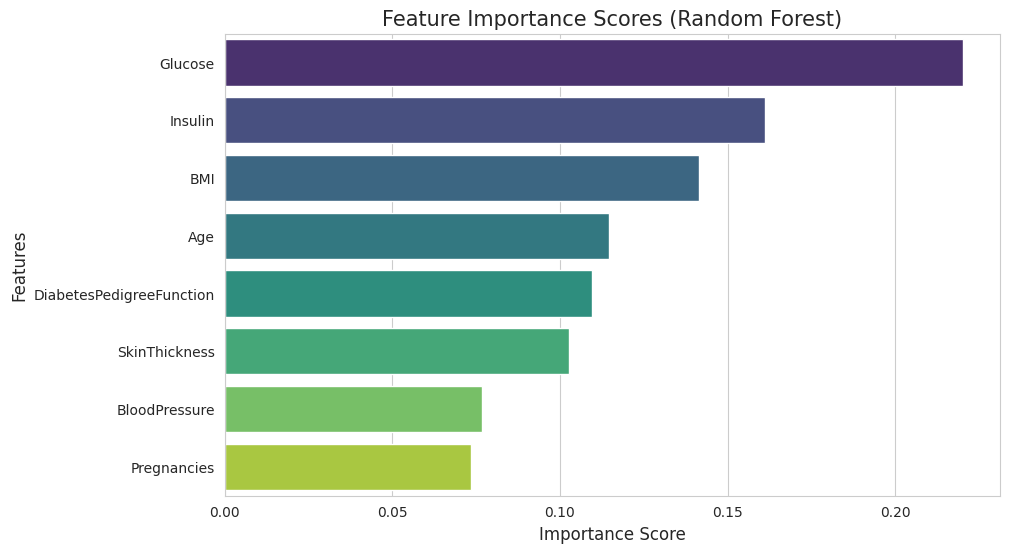

---Feature Importance Table---
                    Feature  Importance
1                   Glucose    0.220054
4                   Insulin    0.161127
5                       BMI    0.141517
7                       Age    0.114715
6  DiabetesPedigreeFunction    0.109669
3             SkinThickness    0.102681
2             BloodPressure    0.076878
0               Pregnancies    0.073359


In [481]:
from sklearn.ensemble import RandomForestClassifier

# 1. Prepare your data
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 2. Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# 3. Get Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns

# 4. Create a DataFrame for easy plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 5. Plot the scores
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title('Feature Importance Scores (Random Forest)', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

# 6. Print the raw scores
print('---Feature Importance Table---')
print(importance_df)


Decision Tree Classifier

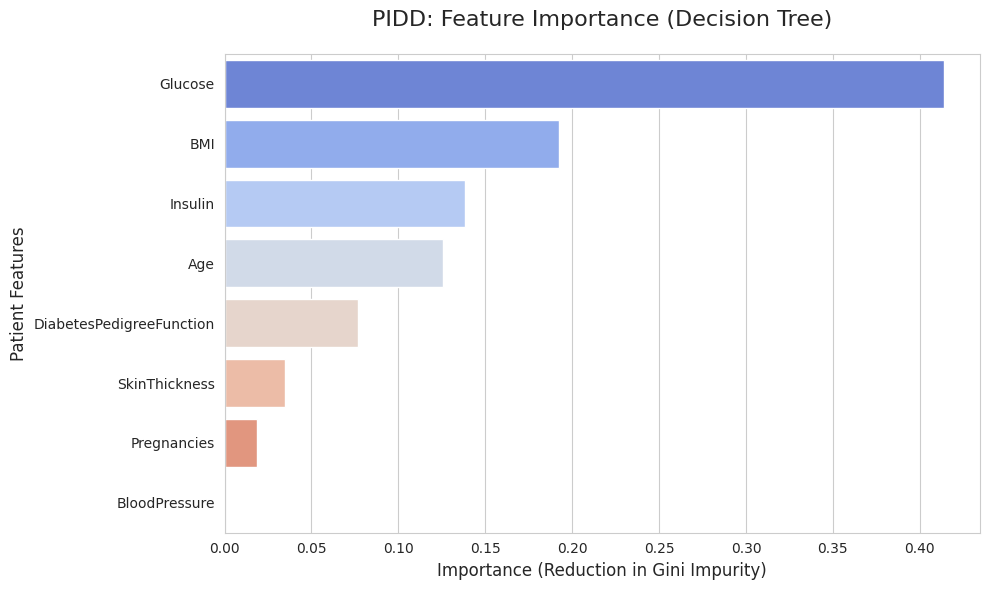

--- Feature Importance Table ---
                 Feature  Importance_Score
                 Glucose          0.413910
                     BMI          0.192300
                 Insulin          0.138061
                     Age          0.125486
DiabetesPedigreeFunction          0.076687
           SkinThickness          0.034708
             Pregnancies          0.018849
           BloodPressure          0.000000


In [482]:
from sklearn.tree import DecisionTreeClassifier

# 1. Prepare Features and Target
# Using your imputed dataframe 'df'
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 2. Split data (standard 80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Fit Decision Tree
# We set a max_depth to ensure the importance scores are meaningful and not overfitted
dt_classifier = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
dt_classifier.fit(X_train, y_train)

# 4. Calculate Importance Scores
importance_scores = dt_classifier.feature_importances_
feature_names = X.columns

# 5. Create a clean DataFrame for the results
dt_importance_results = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importance_scores
}).sort_values(by='Importance_Score', ascending=False)

# 6. Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid") # Makes the plot look professional

# Create horizontal bar plot
plot = sns.barplot(
    x='Importance_Score',
    y='Feature',
    data=dt_importance_results,
    palette='coolwarm'
)

# Add title and labels
plt.title('PIDD: Feature Importance (Decision Tree)', fontsize=16, pad=20)
plt.xlabel('Importance (Reduction in Gini Impurity)', fontsize=12)
plt.ylabel('Patient Features', fontsize=12)

# Add the actual score values on the bars for clarity

plt.tight_layout()
plt.show()

# 7. Print the table for your project report
print("--- Feature Importance Table ---")
print(dt_importance_results.to_string(index=False))


#### Observations
* The selected features are ```Glucose```, ```BMI``` and ```Insulin```.

## Derived Features

### Case 1: